# An Educational Study of Diffusion and Ornstein-Uhlenbeck Models in Equity Markets

**Author:** Dmitri Bolt  
**Course project:** Stochastic Differential Equations

## 1. Introduction

This notebook presents a small educational study of how stochastic differential equations can be used to interpret stock-market data.

The goal is not to build a full econometric model of the market. Instead, the notebook uses real equity data to illustrate how the language of diffusion processes and Ornstein-Uhlenbeck dynamics can describe randomness, trend, and mean reversion in financial time series.

The emphasis is on visual interpretation, simple empirical diagnostics, and simulation-based intuition.

## 2. Research objective and simplified scope

The original project proposal is intentionally simplified in this notebook.

The study focuses on two main ideas:

1. **Diffusion intuition** as a useful educational approximation for stock-market randomness.
2. **Ornstein-Uhlenbeck-style interpretation** for detrended equity-related time series.

The notebook therefore keeps the exposition compact and visually interpretable.

A central idea of the notebook is the following:

> **OU is more meaningful after detrending.**

## 3. Short mathematical background

Following **Definition 2.2.1** in **Chapter 2.2** of Øksendal, **Brownian motion** $B_t$ is the basic noise source used throughout the theory of stochastic differential equations.

Following **Definition 4.1.1** and **Theorem 4.1.2**, an Itô process is introduced in the textbook in integral form as

$$X_t = X_0 + \int_0^t u(s,\omega)\,ds + \int_0^t v(s,\omega)\,dB_s, \tag{4.1.3}$$

and then in shorter differential form as

$$dX_t = u\,dt + v\,dB_t. \tag{4.1.6}$$

In **Chapter 5.1**, Øksendal studies the multiplicative growth model

$$dN_t = rN_t\,dt + \alpha N_t\,dB_t, \tag{5.1.3}$$

whose solution is the geometric Brownian motion

$$N_t = N_0 \exp\!\left(\left(r - \frac{1}{2}\alpha^2\right)t + \alpha B_t\right). \tag{5.1.5}$$

For mean reversion, the notebook takes the textbook OU reference form from **Exercise 5.7**,

$$dX_t = (m - X_t)\,dt + u\,dB_t. \tag{5.7}$$

Later, when the notebook discusses empirical calibration, it uses the same mean-reverting idea with an explicit speed parameter, but the textbook reference point remains **Exercise 5.7**.

## 4. Data and preprocessing

The starting stock universe is taken from `nasdaq_screener_100.csv`. The working download window in this notebook is set to `2023-01-01` - `2026-04-13`, and the actual downloaded panel currently spans from **2023-01-03** to **2026-04-10**.

The preprocessing pipeline keeps five related objects:

1. prices
2. log-prices
3. raw log-returns
4. detrended log-prices
5. detrended log-returns

This separation is important because the notebook uses raw data for diffusion-style intuition and detrended data for the OU-style interpretation.

In [16]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from log_returns import LogReturns
from notebook_support import (
    build_representative_diagnostics,
    compute_autocorrelation_table,
    configure_notebook_style,
    discrete_residual_std_to_ou_diffusion_scale,
    display_available_animations,
    ensure_animation_assets,
    fit_simple_ou_parameters,
    plot_autocorrelation_table,
    plot_detrended_levels_with_rolling_mean,
    plot_empirical_vs_simulated_ou,
    plot_raw_vs_detrended,
    plot_return_distributions,
    plot_rolling_diagnostics,
    plot_simulated_model_paths,
    simulate_brownian_paths,
    simulate_gbm_paths,
    simulate_ou_paths,
)

warnings.filterwarnings("ignore")
configure_notebook_style()
%matplotlib inline

In [17]:
df_symbols = pd.read_csv("nasdaq_screener_100.csv")
symbols = df_symbols["Symbol"].astype(str).dropna().reset_index(drop=True).tolist()

print(f"Number of symbols in the initial universe: {len(symbols)}")
symbols[:10]

Number of symbols in the initial universe: 100


['NVDA',
 'MSFT',
 'AAPL',
 'GOOG',
 'GOOGL',
 'AMZN',
 'META',
 'AVGO',
 'TSLA',
 'BRK/B']

In [18]:
log_returns_object = LogReturns(
    symbols_local=symbols,
    start_date_local="2023-01-01",
    end_date_local="2026-04-13",
)

prices_df = log_returns_object.get_prices()
log_prices_df = log_returns_object.get_log_prices()
log_returns_df = log_returns_object.get_log_returns()
detrended_log_prices_df = log_returns_object.get_detrended_log_prices()
detrended_returns_df = log_returns_object.get_detrended_log_returns()

[*********************100%***********************]  95 of 95 completed


In [19]:
summary_dict = log_returns_object.get_summary()
summary_dict["first_available_date"] = prices_df.index.min().strftime("%Y-%m-%d")
summary_dict["last_available_date"] = prices_df.index.max().strftime("%Y-%m-%d")

summary_df = pd.DataFrame(
    {"value": list(summary_dict.values())},
    index=list(summary_dict.keys()),
).rename_axis("metric")

summary_df

,value
metric,
start_date,2023-01-01
end_date,2026-04-13
input_symbols_count,100
filtered_symbols_count,95
retained_symbols_count,94
filtered_symbols,"[NVDA, MSFT, AAPL, GOOG, GOOGL, AMZN, META, AV..."
retained_symbols,"[AAPL, ABBV, ABT, ADBE, ADI, ADP, AMAT, AMD, A..."
dropped_symbols_with_missing_history,[GEV]
dropped_symbols_with_non_positive_prices,[]


## 5. Representative stocks

The full universe is useful for the overall statistical picture, but detailed plots are easier to read when we focus on a few recognizable examples.

Based on a preliminary empirical screening, the notebook starts with the following representative stocks:

- `NVDA`
- `META`
- `GOOG`

Alternative candidates kept in reserve are `AAPL`, `AMZN`, `NFLX`, and `CAT`.

Scientifically, `GOOG` is preferred over `AAPL` because it gives a clearer before/after detrending contrast: the raw log-price trend is stronger, and the detrended oscillations are more visible without becoming too noisy.

In [20]:
representative_symbols = ["NVDA", "META", "GOOG"]
alternative_symbols = ["AAPL", "AMZN", "NFLX", "CAT"]

available_representatives = [symbol for symbol in representative_symbols if symbol in prices_df.columns]
available_alternatives = [symbol for symbol in alternative_symbols if symbol in prices_df.columns]

print("Representative symbols:", available_representatives)
print("Alternative candidates:", available_alternatives)

Representative symbols: ['NVDA', 'META', 'GOOG']
Alternative candidates: ['AAPL', 'AMZN', 'NFLX', 'CAT']


In [21]:
focus_symbols = available_representatives + available_alternatives
representative_diagnostics_df = build_representative_diagnostics(
    log_prices_df=log_prices_df,
    detrended_log_prices_df=detrended_log_prices_df,
    log_returns_df=log_returns_df,
    focus_symbols=focus_symbols,
)

representative_diagnostics_df.round(4)

,symbol,raw_trend_r2,lag1_autocorr_detrended_level,zero_crossings_detrended_level,raw_return_std,detrended_level_std
0,NVDA,0.8833,0.9916,24,0.0306,0.2362
2,GOOG,0.8663,0.9880,41,0.0187,0.1207
5,NFLX,0.8621,0.9913,32,0.0214,0.1619
6,CAT,0.8370,0.9902,42,0.0188,0.1347
4,AMZN,0.8316,0.9840,46,0.0201,0.1128
1,META,0.8220,0.9919,28,0.0237,0.1867
3,AAPL,0.7818,0.9817,44,0.0160,0.0838


## 6. Raw vs detrended comparison

This section gives the first visual argument for the main narrative of the notebook. The left column shows raw log-prices, while the right column shows the same series after linear detrending.

The goal is not to claim that the detrended data are a perfect OU process. The goal is to show that detrending often makes the mean-reverting intuition more plausible and visually interpretable.

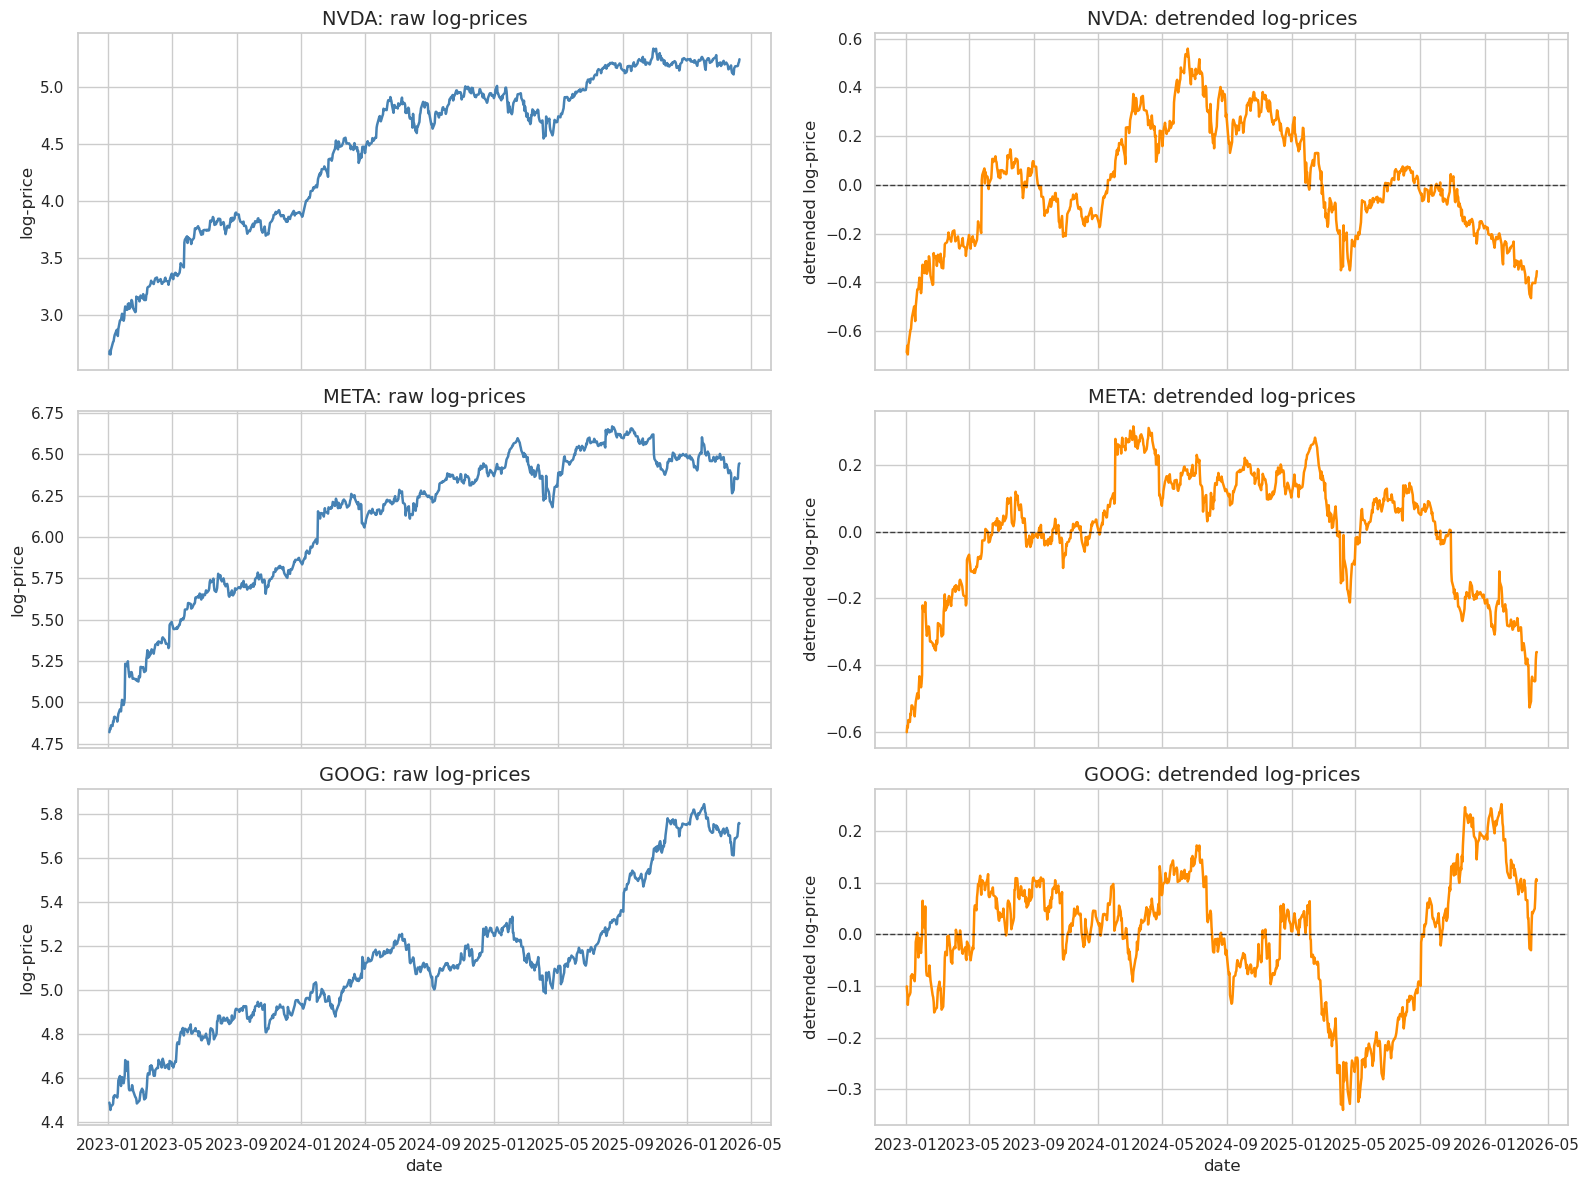

In [22]:
plot_raw_vs_detrended(
    log_prices_df=log_prices_df,
    detrended_log_prices_df=detrended_log_prices_df,
    symbols=available_representatives,
)

## 7. Return distributions

The next comparison looks at raw log-returns and detrended log-returns. This helps separate the diffusion-style increment intuition from the OU-style interpretation that is tied more closely to detrended levels and their increments.

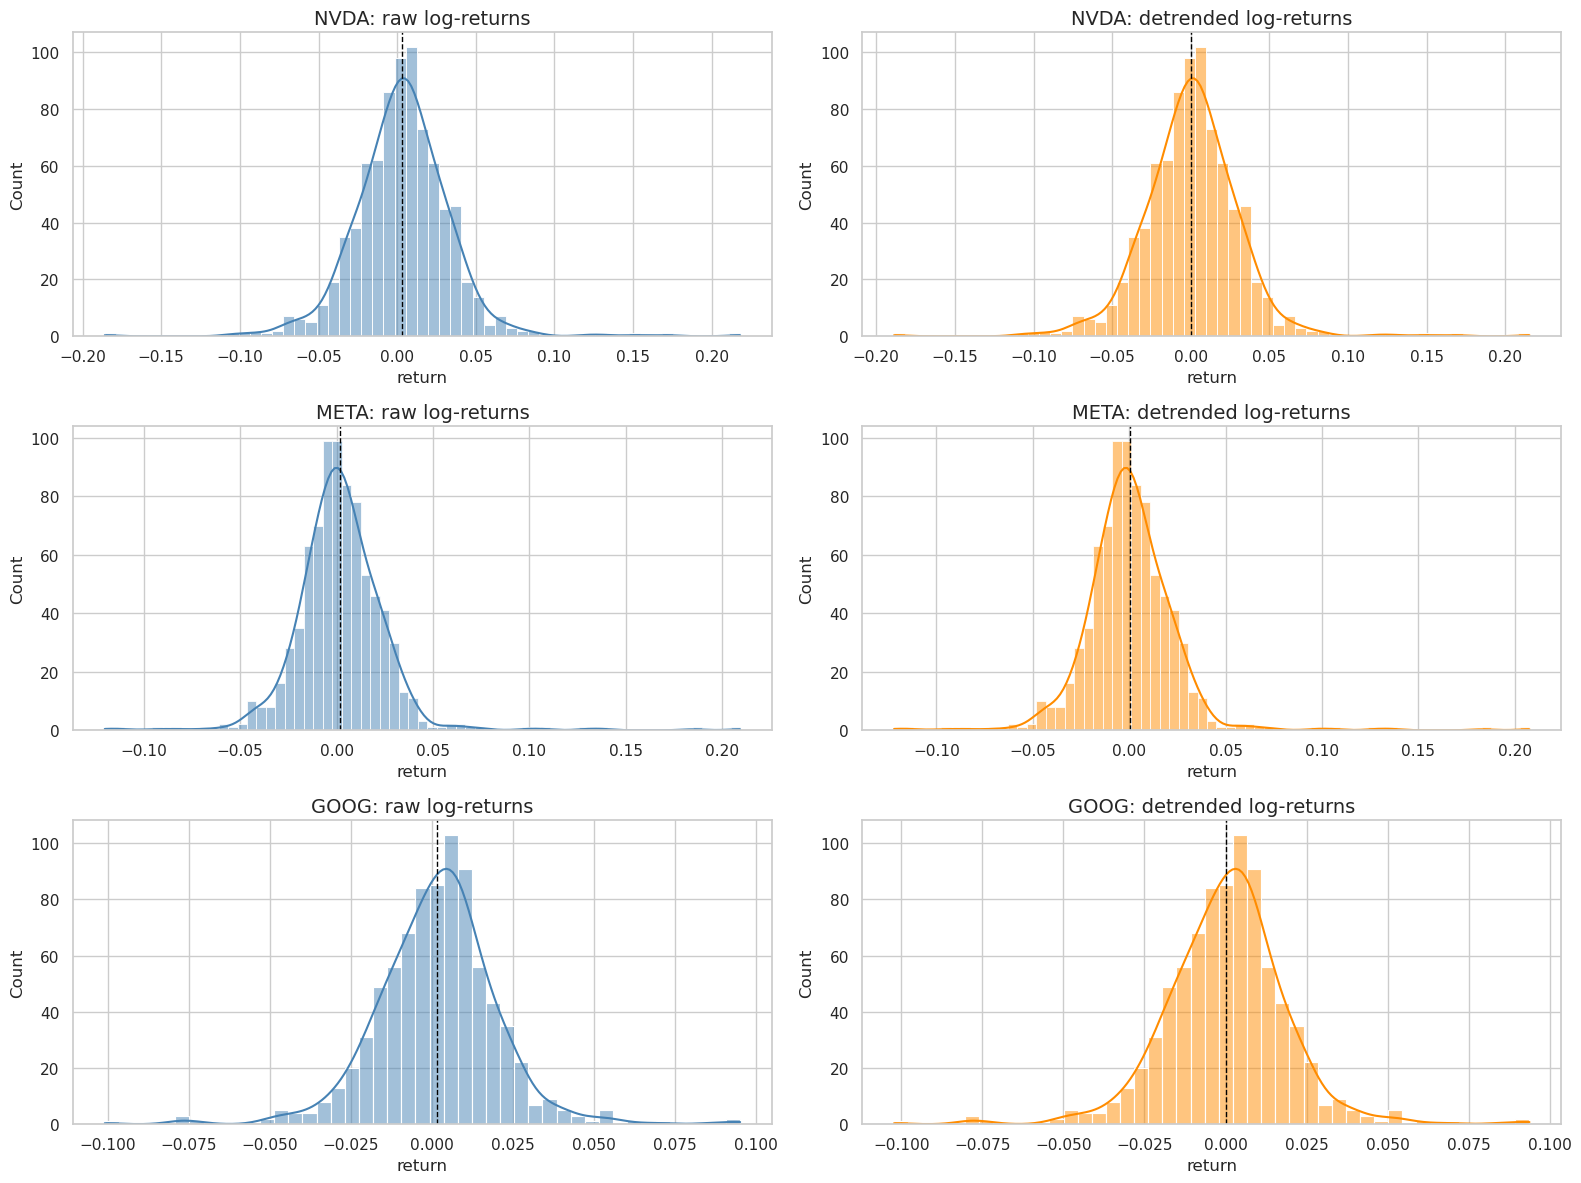

In [23]:
plot_return_distributions(
    log_returns_df=log_returns_df,
    detrended_returns_df=detrended_returns_df,
    symbols=available_representatives,
)

## 8. Rolling diagnostics for raw log-returns

We now examine rolling mean and rolling volatility for raw log-returns using a **21-trading-day window**.

In a very simple diffusion model with constant parameters, one would expect the local mean to stay close to a stable level and the local volatility to be relatively stable over time. Real equity data are more complicated, so the goal here is not exact validation. Instead, the goal is to show where the diffusion intuition is useful and where the data visibly depart from a constant-parameter picture.

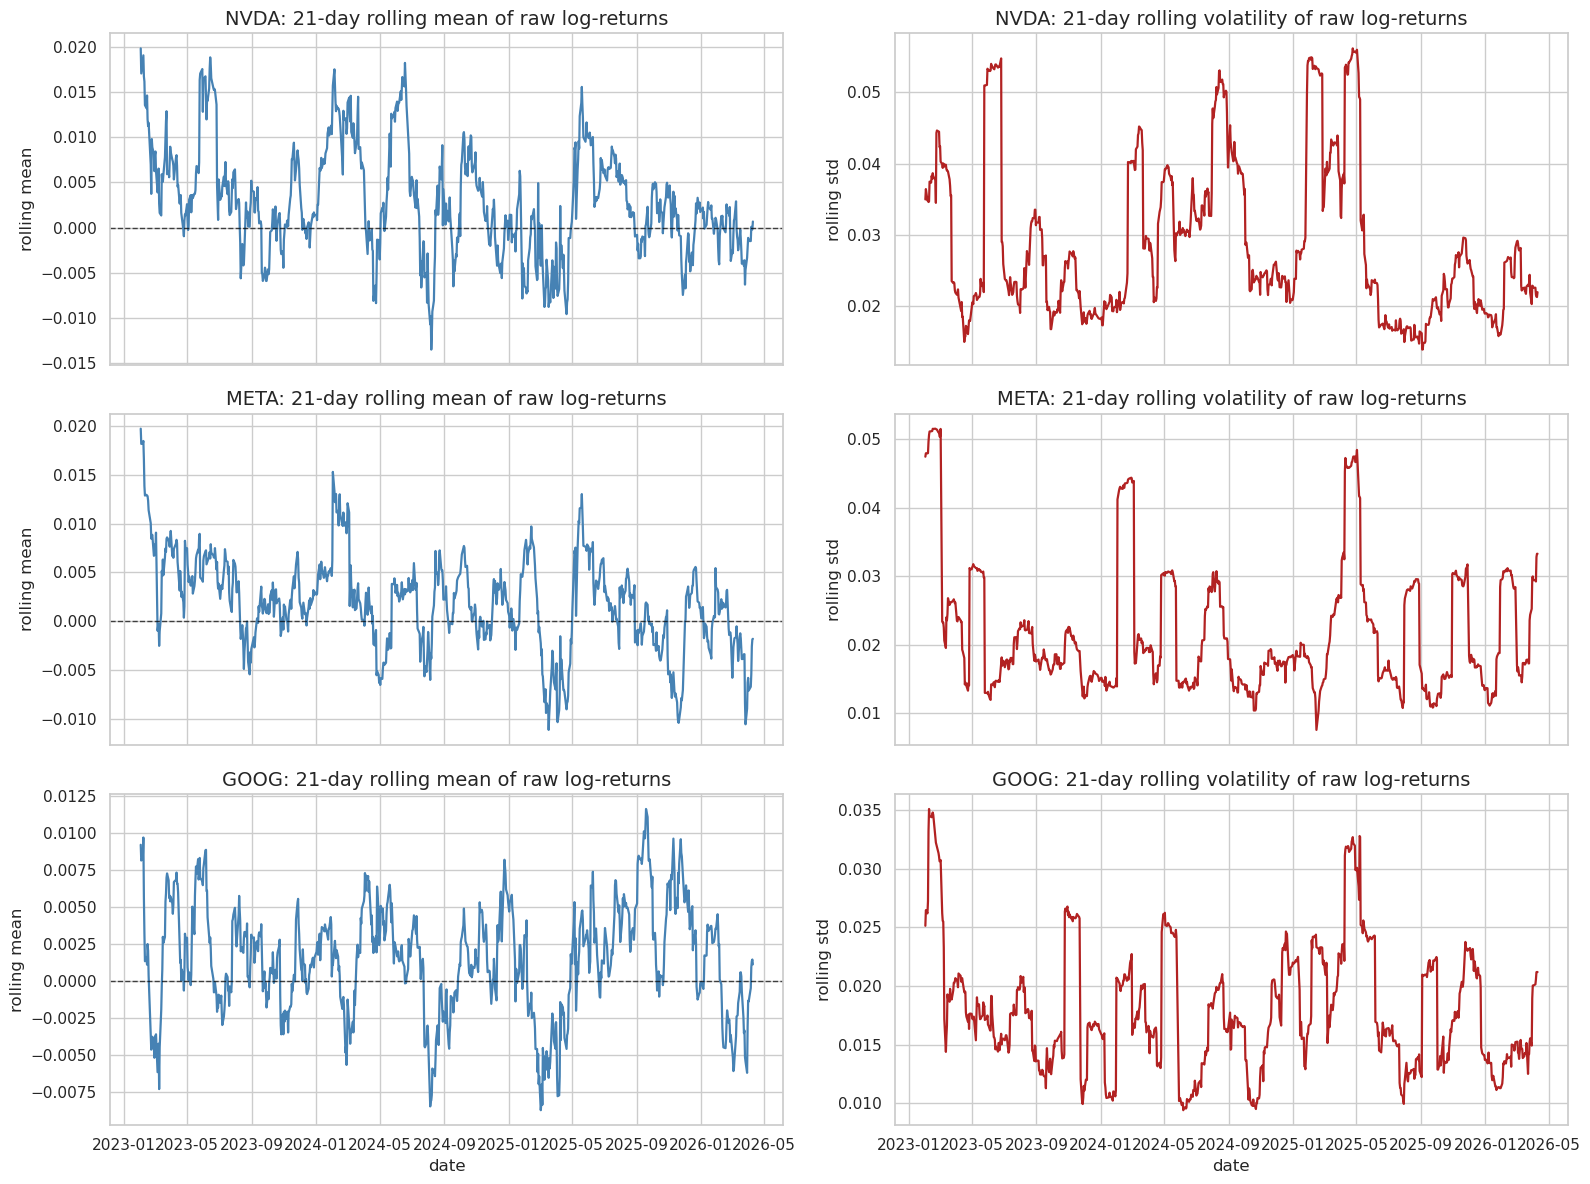

In [24]:
rolling_window = 21
plot_rolling_diagnostics(
    log_returns_df=log_returns_df,
    symbols=available_representatives,
    rolling_window=rolling_window,
)

## 9. Autocorrelation of detrended levels

For the OU-style interpretation, the main object is not raw returns but **detrended log-prices**. A mean-reverting process typically shows positive autocorrelation that decays with lag, because the current state still contains information about nearby future states.

This does **not** prove that the data follow an exact OU law. However, it does provide an empirical signature consistent with OU-style persistence in detrended levels.

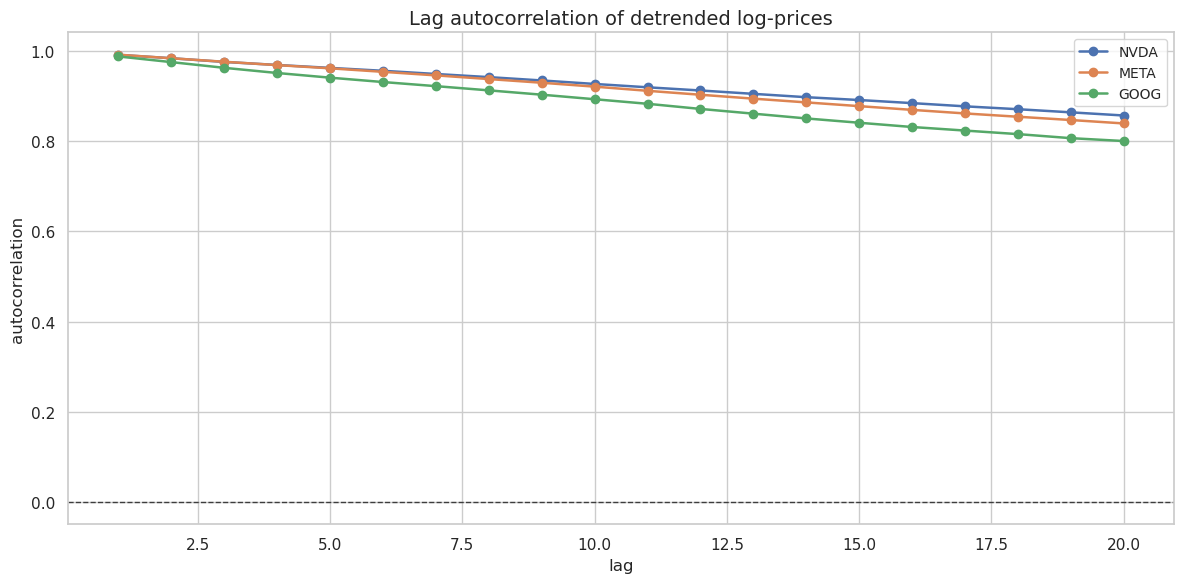

,NVDA,META,GOOG
1,0.9916,0.9919,0.9880
2,0.9840,0.9840,0.9754
3,0.9758,0.9762,0.9628
4,0.9691,0.9688,0.9513
5,0.9626,0.9617,0.9409
6,0.9562,0.9539,0.9312
7,0.9491,0.9460,0.9221
8,0.9421,0.9378,0.9128
9,0.9347,0.9297,0.9032
10,0.9270,0.9210,0.8931


In [25]:
autocorrelation_df = compute_autocorrelation_table(
    detrended_log_prices_df=detrended_log_prices_df,
    symbols=available_representatives,
    max_lag=20,
)

plot_autocorrelation_table(autocorrelation_df)
autocorrelation_df.round(4)

## 10. Simple OU-style parameter intuition

The textbook mean-reverting OU reference point used in this notebook is

$$dX_t = (m - X_t)\,dt + u\,dB_t. \tag{5.7}$$

In the empirical code below, the same idea is written with an explicit speed-of-reversion parameter and then approximated with a first-order regression in detrended levels.

The key empirical quantity is the persistence coefficient `phi_hat`: values below 1 suggest pullback toward a long-run level rather than a pure random walk in levels.

This is only an **educational approximation**. It is not a full econometric calibration of an OU diffusion. Its purpose is to connect the detrended empirical series with a familiar mean-reversion parameterization.

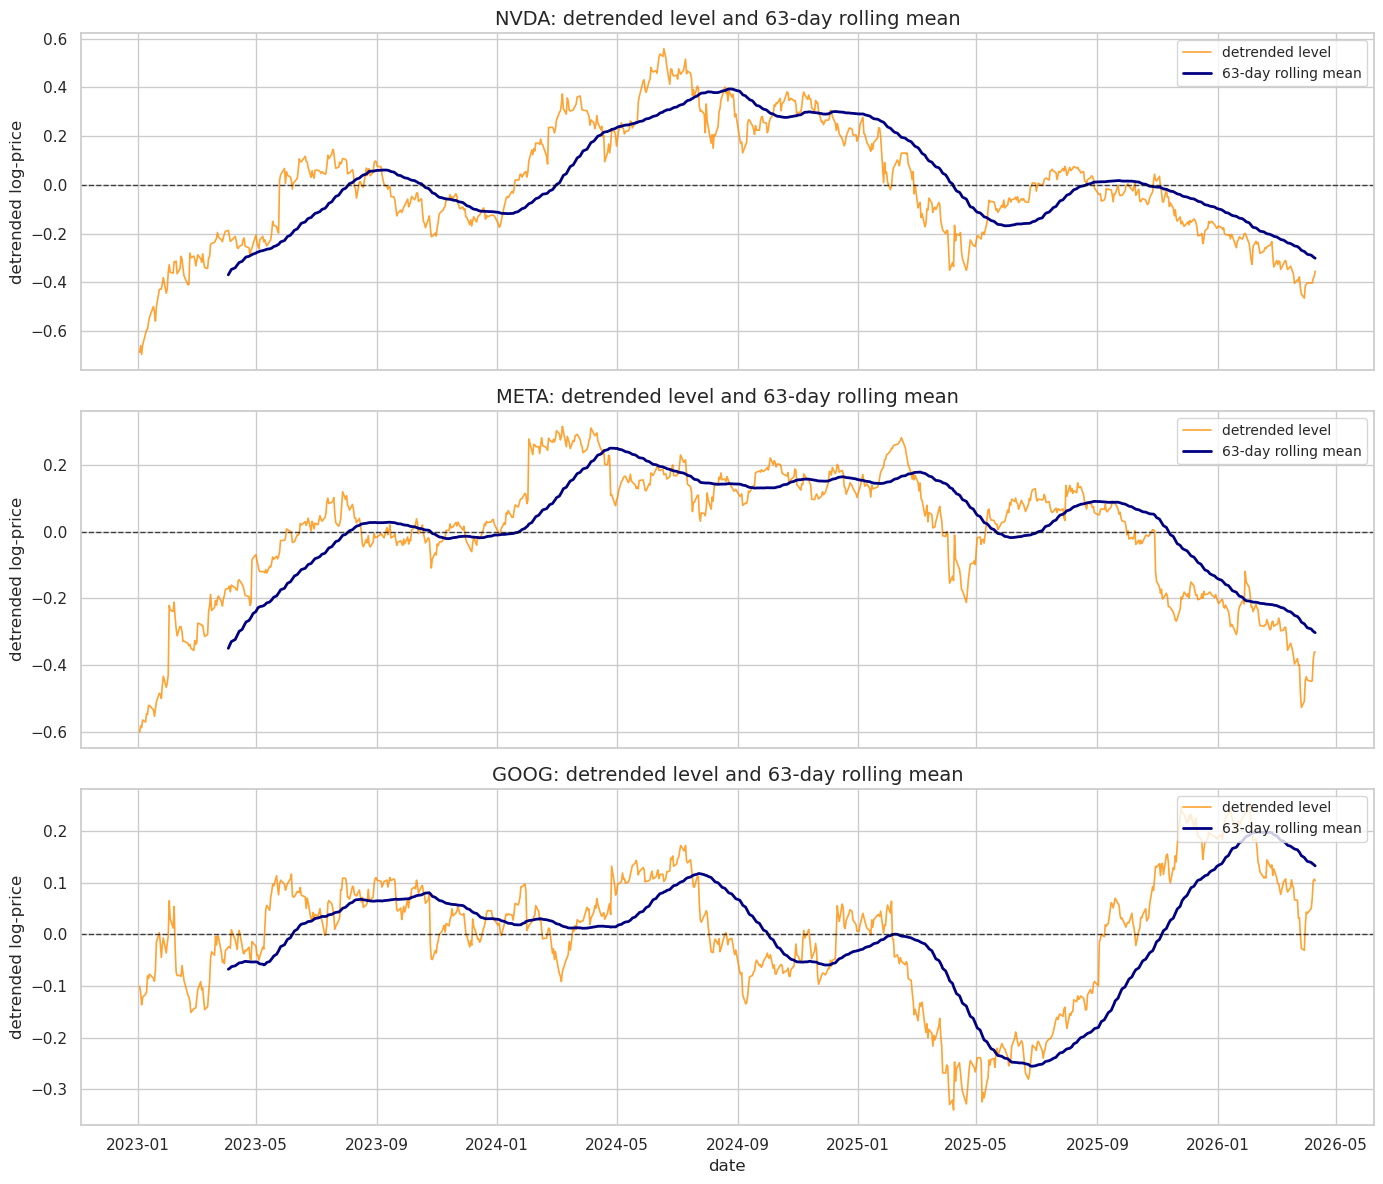

In [26]:
plot_detrended_levels_with_rolling_mean(
    detrended_log_prices_df=detrended_log_prices_df,
    symbols=available_representatives,
    window=63,
)

In [27]:
ou_parameter_df = fit_simple_ou_parameters(
    detrended_log_prices_df=detrended_log_prices_df,
    symbols=available_representatives,
)

ou_parameter_df.round(4)

,symbol,alpha_hat,phi_hat,theta_hat,half_life_days,long_run_mean_hat,sigma_hat
0,NVDA,0.0004,0.9878,0.0123,56.3957,0.0337,0.0305
1,META,0.0003,0.9879,0.0122,56.7781,0.0245,0.0236
2,GOOG,0.0002,0.9880,0.0121,57.4022,0.0207,0.0187


## 11. Simulation section

The simulation block connects the empirical plots to three canonical stochastic models from the textbook.

- **Brownian motion** provides the basic random noise source from **Chapter 2.2**.
- **Geometric Brownian motion** follows the multiplicative growth model from **Chapter 5.1**.
- **Ornstein-Uhlenbeck dynamics** provide a stylized mean-reverting benchmark for detrended levels, consistent with **Exercise 5.7** and **Example 12.3.5**.

The goal is not to claim that the market literally follows one of these models. The goal is to compare their qualitative behavior with the empirical series and make the SDE language visually concrete.

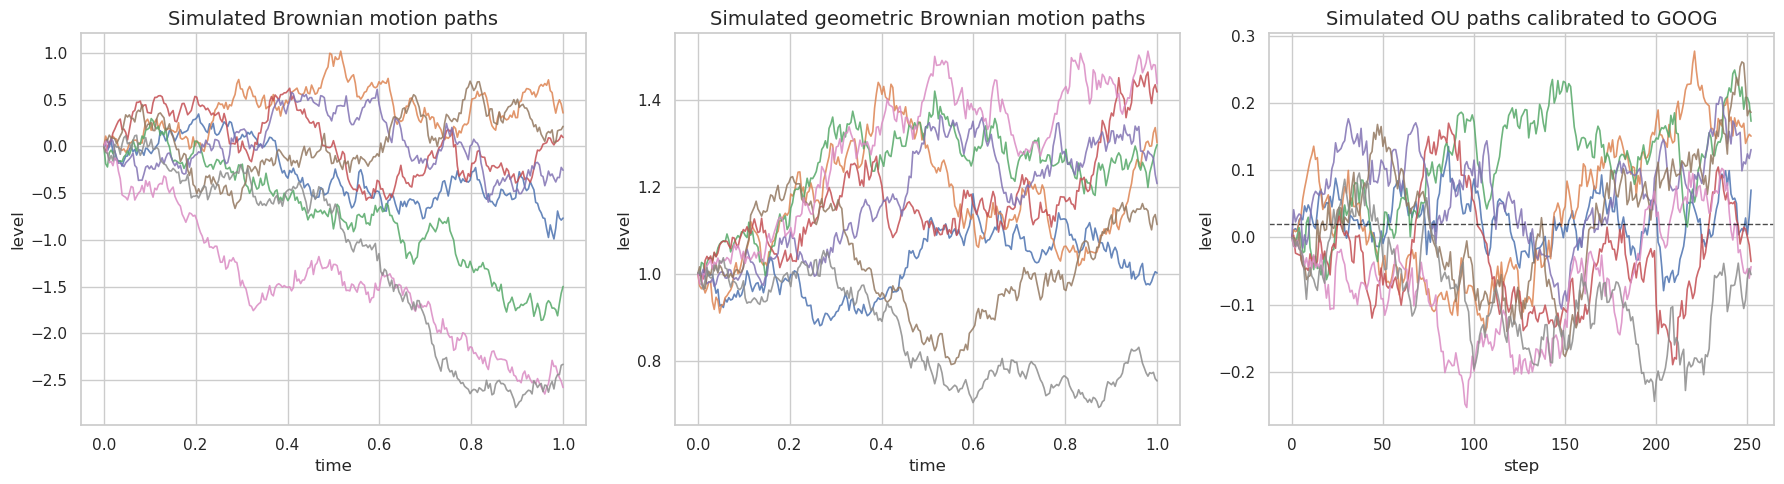

In [28]:
rng = np.random.default_rng(42)

brownian_time, brownian_paths = simulate_brownian_paths(
    n_paths=8,
    n_steps=252,
    dt=1.0 / 252.0,
    rng=rng,
)

gbm_time, gbm_paths = simulate_gbm_paths(
    n_paths=8,
    n_steps=252,
    dt=1.0 / 252.0,
    x0=1.0,
    drift=0.12,
    volatility=0.25,
    rng=rng,
)

ou_reference_symbol = "GOOG" if "GOOG" in set(ou_parameter_df["symbol"]) else available_representatives[0]
ou_reference_row = ou_parameter_df.loc[ou_parameter_df["symbol"] == ou_reference_symbol].iloc[0]
ou_theta = float(ou_reference_row["theta_hat"])
ou_mean_level = float(ou_reference_row["long_run_mean_hat"])
ou_sigma_discrete = float(ou_reference_row["sigma_hat"])
ou_diffusion_scale = discrete_residual_std_to_ou_diffusion_scale(
    theta_hat=ou_theta,
    sigma_hat=ou_sigma_discrete,
    dt=1.0,
)

ou_time, ou_paths = simulate_ou_paths(
    n_paths=8,
    n_steps=252,
    dt=1.0,
    x0=0.0,
    theta=ou_theta,
    mean_level=ou_mean_level,
    diffusion_scale=ou_diffusion_scale,
    rng=rng,
)

plot_simulated_model_paths(
    brownian_time=brownian_time,
    brownian_paths=brownian_paths,
    gbm_time=gbm_time,
    gbm_paths=gbm_paths,
    ou_time=ou_time,
    ou_paths=ou_paths,
    ou_mean_level=ou_mean_level,
    ou_reference_symbol=ou_reference_symbol,
)

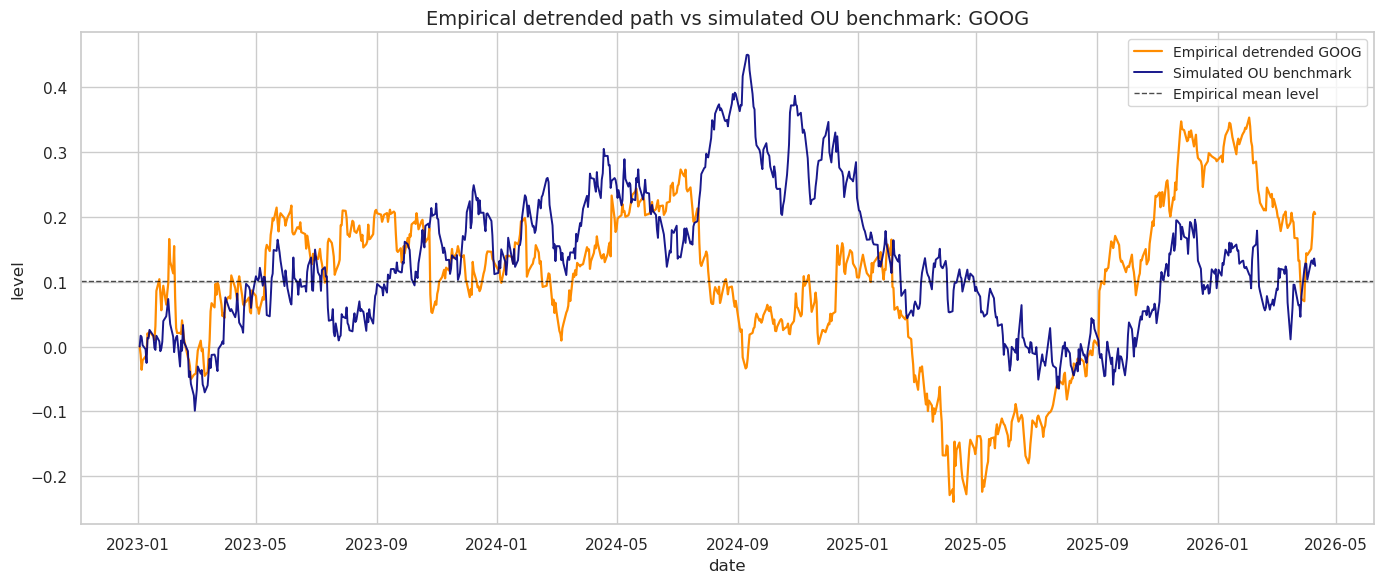

In [29]:
comparison_symbol = ou_reference_symbol
empirical_rescaled = detrended_log_prices_df[comparison_symbol].dropna()
empirical_rescaled = empirical_rescaled - empirical_rescaled.iloc[0]

_, comparison_ou_paths = simulate_ou_paths(
    n_paths=1,
    n_steps=len(empirical_rescaled) - 1,
    dt=1.0,
    x0=float(empirical_rescaled.iloc[0]),
    theta=ou_theta,
    mean_level=float(empirical_rescaled.mean()),
    diffusion_scale=ou_diffusion_scale,
    rng=rng,
)
comparison_ou_series = pd.Series(comparison_ou_paths[0], index=empirical_rescaled.index)

plot_empirical_vs_simulated_ou(
    empirical_series=empirical_rescaled,
    simulated_series=comparison_ou_series,
    symbol=comparison_symbol,
)

### Simulation interpretation

The simulated Brownian paths fluctuate around zero without a built-in trend. The simulated GBM paths tend to drift upward while preserving multiplicative randomness. The simulated OU paths repeatedly pull back toward a long-run level.

This is exactly why the notebook separates raw and detrended data: raw log-prices are visually closer to a drift-dominated growth picture, while detrended levels are more naturally compared with a mean-reverting OU benchmark.

## 12. Optional animations

The GIF generation logic is kept in `notebook_support.py` so that the notebook remains presentation-friendly.

Each colored line in the GIFs denotes one independently simulated path of the corresponding model. In the OU animation, the dashed horizontal line marks the estimated long-run mean.

If `regenerate_animation_assets = True`, the helper module rebuilds the files in `animation_outputs/`. Otherwise, the notebook simply loads the GIFs that are already stored on disk.

brownian: animation_outputs/brownian_motion.gif
Brownian GIF: each colored line is one independently simulated Brownian path.


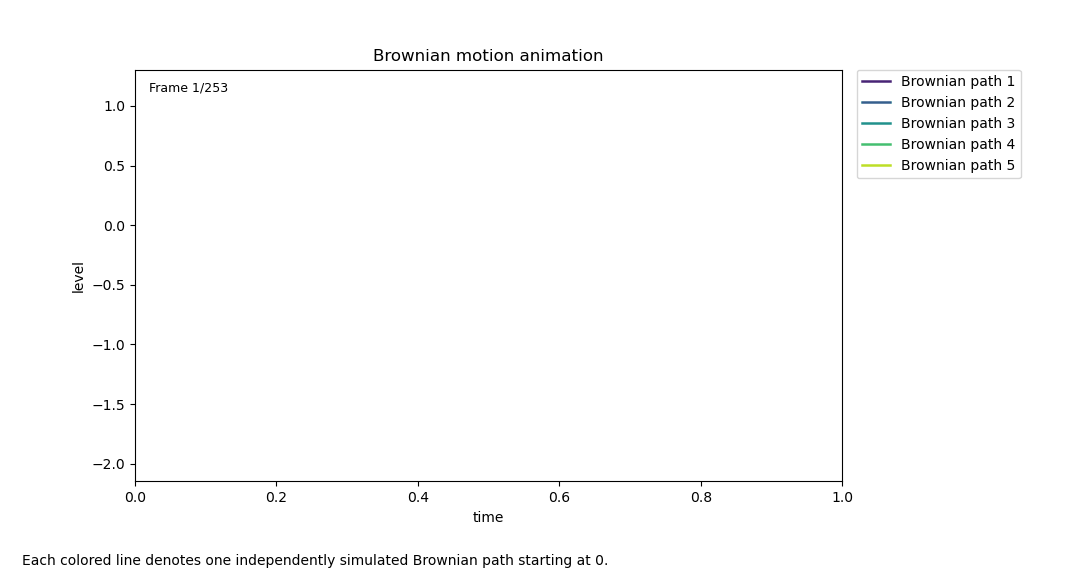

ou: animation_outputs/ou_process.gif
OU GIF: each colored line is one independently simulated OU path; the dashed line is the long-run level.


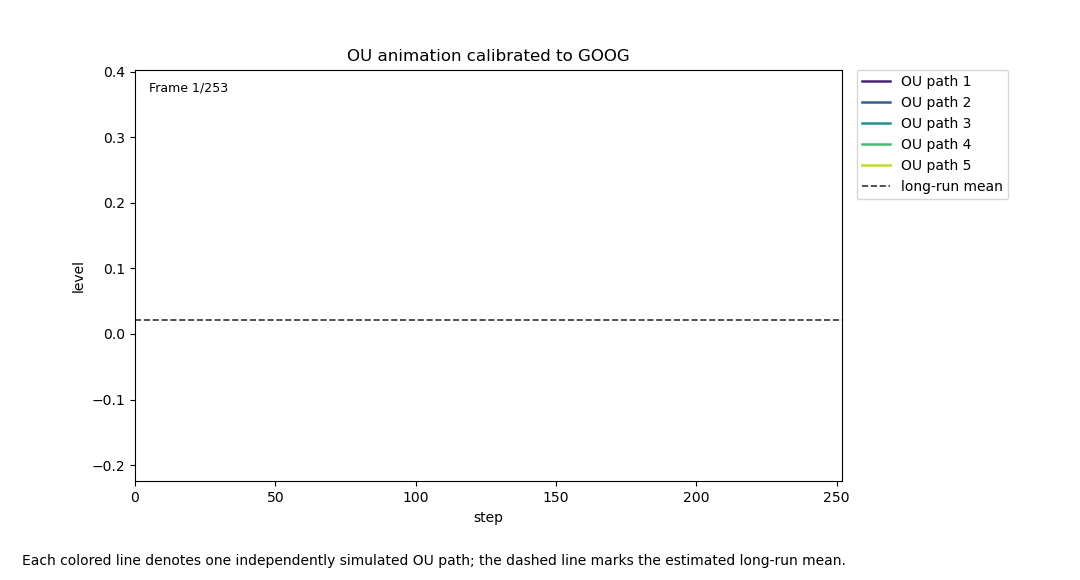

In [30]:
regenerate_animation_assets = False
animation_paths = ensure_animation_assets(
    brownian_time=brownian_time,
    brownian_paths=brownian_paths,
    ou_time=ou_time,
    ou_paths=ou_paths,
    ou_mean_level=ou_mean_level,
    ou_reference_symbol=ou_reference_symbol,
    regenerate=regenerate_animation_assets,
)

display_available_animations(animation_paths)

## 13. Main findings

The notebook suggests the following main empirical conclusions.

1. The diffusion language is useful as an educational approximation for stock-market randomness.
2. Raw equity series are strongly trend-dominated, so OU-style interpretation is not very natural at the level of unprocessed prices.
3. After detrending, several representative series become visually and statistically more compatible with mean-reverting intuition.
4. A simple AR(1) approximation in detrended levels supports this interpretation by showing persistence below the unit-root benchmark.
5. Simulated Brownian, GBM, and OU trajectories help clarify what each canonical model captures well and what it misses.

## 14. Limitations

This notebook is intentionally a small educational mini research project, so several limitations should be stated explicitly.

- The analysis uses daily data only.
- Detrending is linear and intentionally simple.
- The OU interpretation is educational rather than fully econometric.
- The representative stocks are chosen for readability and illustration, not for exhaustive cross-sectional inference.
- The simulation section is designed for intuition, not for formal model testing.

## 15. Conclusion

Using the terminology and basic models of Øksendal, this notebook shows that stochastic differential equations provide a useful language for discussing equity-market randomness in a compact and visual way.

Brownian motion and geometric Brownian motion help explain diffusion-style intuition for random fluctuations and growth under uncertainty. Ornstein-Uhlenbeck dynamics become more meaningful after detrending, because detrended levels are much more naturally interpreted through mean reversion than raw prices are.

For a small student mini research project, this is already a useful conclusion: the SDE framework does not perfectly describe the market, but it gives an interpretable bridge between probability theory, stochastic calculus, and real financial data.

At the same time, the present notebook creates a clean basis for further continuation of the research. Natural next steps include:

- diffusion diagnostics across time aggregation, including variance scaling, weak serial dependence, and approximate Gaussianity;
- realized quadratic variation analysis;
- PCA-based market-factor extraction;
- OU analysis of a detrended factor;
- sparse-jump extensions;
- a more explicit link from fitted SDE baselines to generators and Fokker-Planck dynamics.

In this sense, the current study should be viewed not as an endpoint but as a structured first stage of a broader empirical SDE project.